This notebook is meant to show you the most basic workflow for processing a single event with the GAMPixPy framework.  It follows a very similar script which you can find in `examples/gampix_sim.py`

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt

from gampixpy import detector, input_parsing, plotting, config, output

import torch

if torch.cuda.is_available():
    device = torch.device('cuda')
    # Set the default device to CUDA
    torch.set_default_device(device)
    print(f"Default device set to: {torch.cuda.get_device_name(device)}")
else:
    device = torch.device('cpu')
    print("CUDA is not available, using CPU")

CUDA is not available, using CPU


In [2]:
detector_config = config.preset_detector_configs['far_detector_vd']
physics_config = config.default_physics_params
readout_config = config.preset_readout_configs['demo_large_pixels']

detector_model = detector.DetectorModel(detector_params=detector_config,
                                        physics_params=physics_config,
                                        readout_params=readout_config,
                                       )

In [6]:
input_file = '../inputs/muon_1-4GeV.h5'
input_parser = input_parsing.EdepSimParser(input_file,
                                           readout_config=readout_config)

event_index = 3
event_data = input_parser.get_sample(event_index)
event_meta = input_parser.get_meta(event_index)

In [7]:
detector_model.drift(event_data)
detector_model.readout(event_data)

simulating coarse grid...
coarse time series built
coarse hit finding...
simulating fine grid...
pixel time series built
pixel hit finding...
found 8 coarse tile hits
found 1900 pixel hits


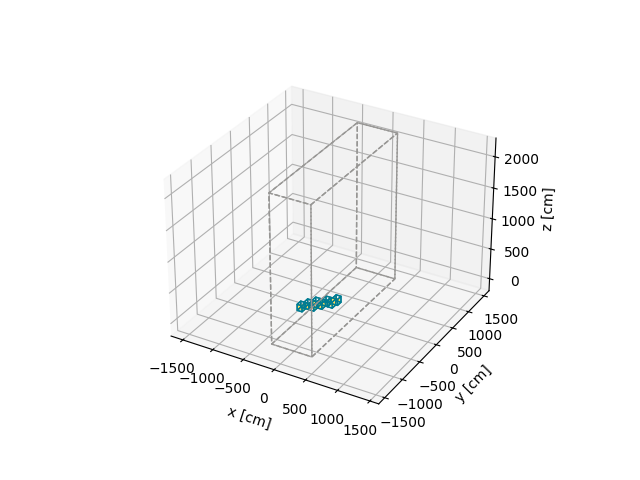

In [9]:
evd = plotting.EventDisplay(event_data)

#evd.plot_raw_track()

evd.plot_drift_volumes(detector_config)

evd.plot_coarse_tile_measurement(readout_config,
                                 physics_config,
                                 detector_config,
                                ) # plot tile hits

evd.plot_pixel_measurement(readout_config,
                               physics_config,
                              detector_config,
                              ) # plot pixel hits

evd.show()